**Project Title:
The Ultimate Cars Dataset 2024 Analysis**

In [124]:
#Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os

**Load the Dataset**


In [84]:
#Setting the working directory and loading the data

os.chdir('/mnt/sdb1/Python/Python For Machine Learning/datasets')

cars_data = pd.read_csv("Cars_Dataset.csv")

**Data Cleaning and Preprocessing**


In [100]:
# Display basic information about the dataset
cars_data_info = cars_data.info()
cars_data_head = cars_data.head()
cars_data_description = cars_data.describe(include='all')
cars_data_info, cars_data_head, cars_data_description


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Company Names              1213 non-null   object 
 1   Cars Names                 1213 non-null   object 
 2   Engines                    1213 non-null   object 
 3   CC/Battery Capacity        1213 non-null   float64
 4   HorsePower                 1213 non-null   float64
 5   Total Speed                1213 non-null   float64
 6   Performance(0 - 100 )KM/H  1213 non-null   float64
 7   Cars Prices                1212 non-null   float64
 8   Fuel Types                 1213 non-null   object 
 9   Seats                      1213 non-null   int64  
 10  Torque                     1213 non-null   float64
dtypes: float64(6), int64(1), object(4)
memory usage: 104.4+ KB


(None,
   Company Names     Cars Names      Engines  CC/Battery Capacity  HorsePower  \
 0       FERRARI  SF90 STRADALE           V8               3990.0       963.0   
 1   ROLLS ROYCE        PHANTOM          V12               6749.0       563.0   
 2          Ford            KA+  1.2L Petrol               1200.0      7085.0   
 3      MERCEDES        GT 63 S           V8               3982.0       630.0   
 4          AUDI     AUDI R8 Gt          V10               5204.0       602.0   
 
    Total Speed  Performance(0 - 100 )KM/H   Cars Prices       Fuel Types  \
 0        340.0                        2.5  1.100000e+06  plug in hyrbrid   
 1        250.0                        5.3  4.600000e+05           Petrol   
 2        165.0                       10.5  1.200015e+09           Petrol   
 3        250.0                        3.2  1.610000e+05           Petrol   
 4        320.0                        3.6  2.532900e+05           Petrol   
 
    Seats    Torque  
 0      2     800.0

In [104]:
# Function to clean numeric columns
def clean_numeric_column(column):
    # Convert column to string to avoid .str accessor issues
    column = column.astype(str)
    # Remove non-numeric characters
    column = column.replace(r'[^\d.,-]', '', regex=True)
    column = column.replace(r'[^0-9.]', '', regex=True)
    # Extract the first valid numeric part
    column = column.str.extract(r'(\d+\.?\d*)')[0]
    # Convert to numeric, coercing errors to NaN
    return pd.to_numeric(column, errors='coerce')

# Cleaning specific numeric columns
numeric_columns_to_clean = ['CC/Battery Capacity', 'HorsePower', 'Total Speed', 
                            'Performance(0 - 100 )KM/H', 'Cars Prices', 'Torque']
for col in numeric_columns_to_clean:
    if col in cars_data.columns:
        cars_data[col] = clean_numeric_column(cars_data[col])

In [105]:
# Handle missing values (Impute numeric columns with the median)
numeric_columns = ['CC/Battery Capacity', 'HorsePower', 'Total Speed', 
                   'Performance(0 - 100 )KM/H', 'Cars Prices', 'Torque']

cars_data[numeric_columns] = cars_data[numeric_columns].fillna(cars_data[numeric_columns].median())


In [107]:
# Detect and remove outliers using the IQR method
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

for col in numeric_columns:
    cars_data = remove_outliers(cars_data, col)


**Exploratory Data Analysis (EDA)**

In [108]:
# Statistical summary
print("Statistical Summary:")
print(cars_data.describe())

Statistical Summary:
       CC/Battery Capacity  HorsePower  Total Speed  \
count           822.000000  822.000000   822.000000   
mean           2630.722749  295.012165   218.309002   
std            1602.372291  152.655838    45.612085   
min               1.240000   61.000000   120.000000   
25%            1591.000000  170.000000   185.000000   
50%            2388.000000  280.000000   210.000000   
75%            3600.000000  400.000000   250.000000   
max            7300.000000  760.000000   340.000000   

       Performance(0 - 100 )KM/H    Cars Prices       Seats       Torque  
count                  822.00000     822.000000  822.000000   822.000000  
mean                     7.15365   62544.372263    5.759124   418.198297  
std                      2.63444   55335.776910   10.812785   188.380083  
min                      2.60000    7200.000000    1.000000    93.000000  
25%                      5.20000   30000.000000    5.000000   265.000000  
50%                      6.90000 

In [109]:
# Correlation matrix
correlation_matrix = cars_data[numeric_columns].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                           CC/Battery Capacity  HorsePower  Total Speed  \
CC/Battery Capacity                   1.000000    0.513703     0.310157   
HorsePower                            0.513703    1.000000     0.738715   
Total Speed                           0.310157    0.738715     1.000000   
Performance(0 - 100 )KM/H            -0.308203   -0.833891    -0.794924   
Cars Prices                           0.390897    0.814141     0.722914   
Torque                                0.467389    0.918942     0.586026   

                           Performance(0 - 100 )KM/H  Cars Prices    Torque  
CC/Battery Capacity                        -0.308203     0.390897  0.467389  
HorsePower                                 -0.833891     0.814141  0.918942  
Total Speed                                -0.794924     0.722914  0.586026  
Performance(0 - 100 )KM/H                   1.000000    -0.647583 -0.737018  
Cars Prices                                -0.647583     1.0000

In [110]:
# Advanced grouping and aggregation
grouped_data = cars_data.groupby('Fuel Types')['Cars Prices'].mean()
print("\nAverage Car Prices by Fuel Type:")
print(grouped_data)


Average Car Prices by Fuel Type:
Fuel Types
CNG/Petrol          11800.000000
Diesel              34189.000000
Diesel/Petrol       55000.000000
Electric            62650.547945
Hybrid              61060.000000
Hybrid (Petrol)    148750.000000
Hybrid/Electric     18000.000000
Hydrogen            46633.333333
Petrol              66005.651591
Petrol/AWD          34500.000000
Petrol/Diesel       45587.500000
Petrol/EV           20500.000000
Petrol/Hybrid       27728.571429
Plug-in Hybrid      31100.000000
Name: Cars Prices, dtype: float64


**Data Visualization**

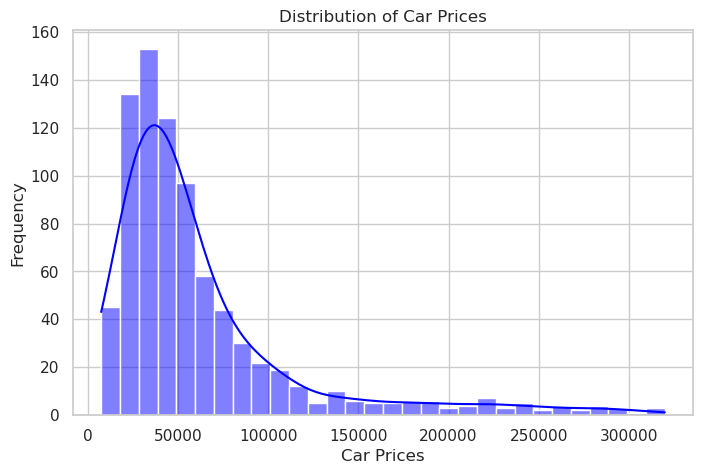

In [112]:
# Set visual style
sns.set(style="whitegrid")

# Histogram for car prices
plt.figure(figsize=(8, 5))
sns.histplot(cars_data['Cars Prices'], kde=True, bins=30, color='blue')
plt.title('Distribution of Car Prices')
plt.xlabel('Car Prices')
plt.ylabel('Frequency')
plt.show()

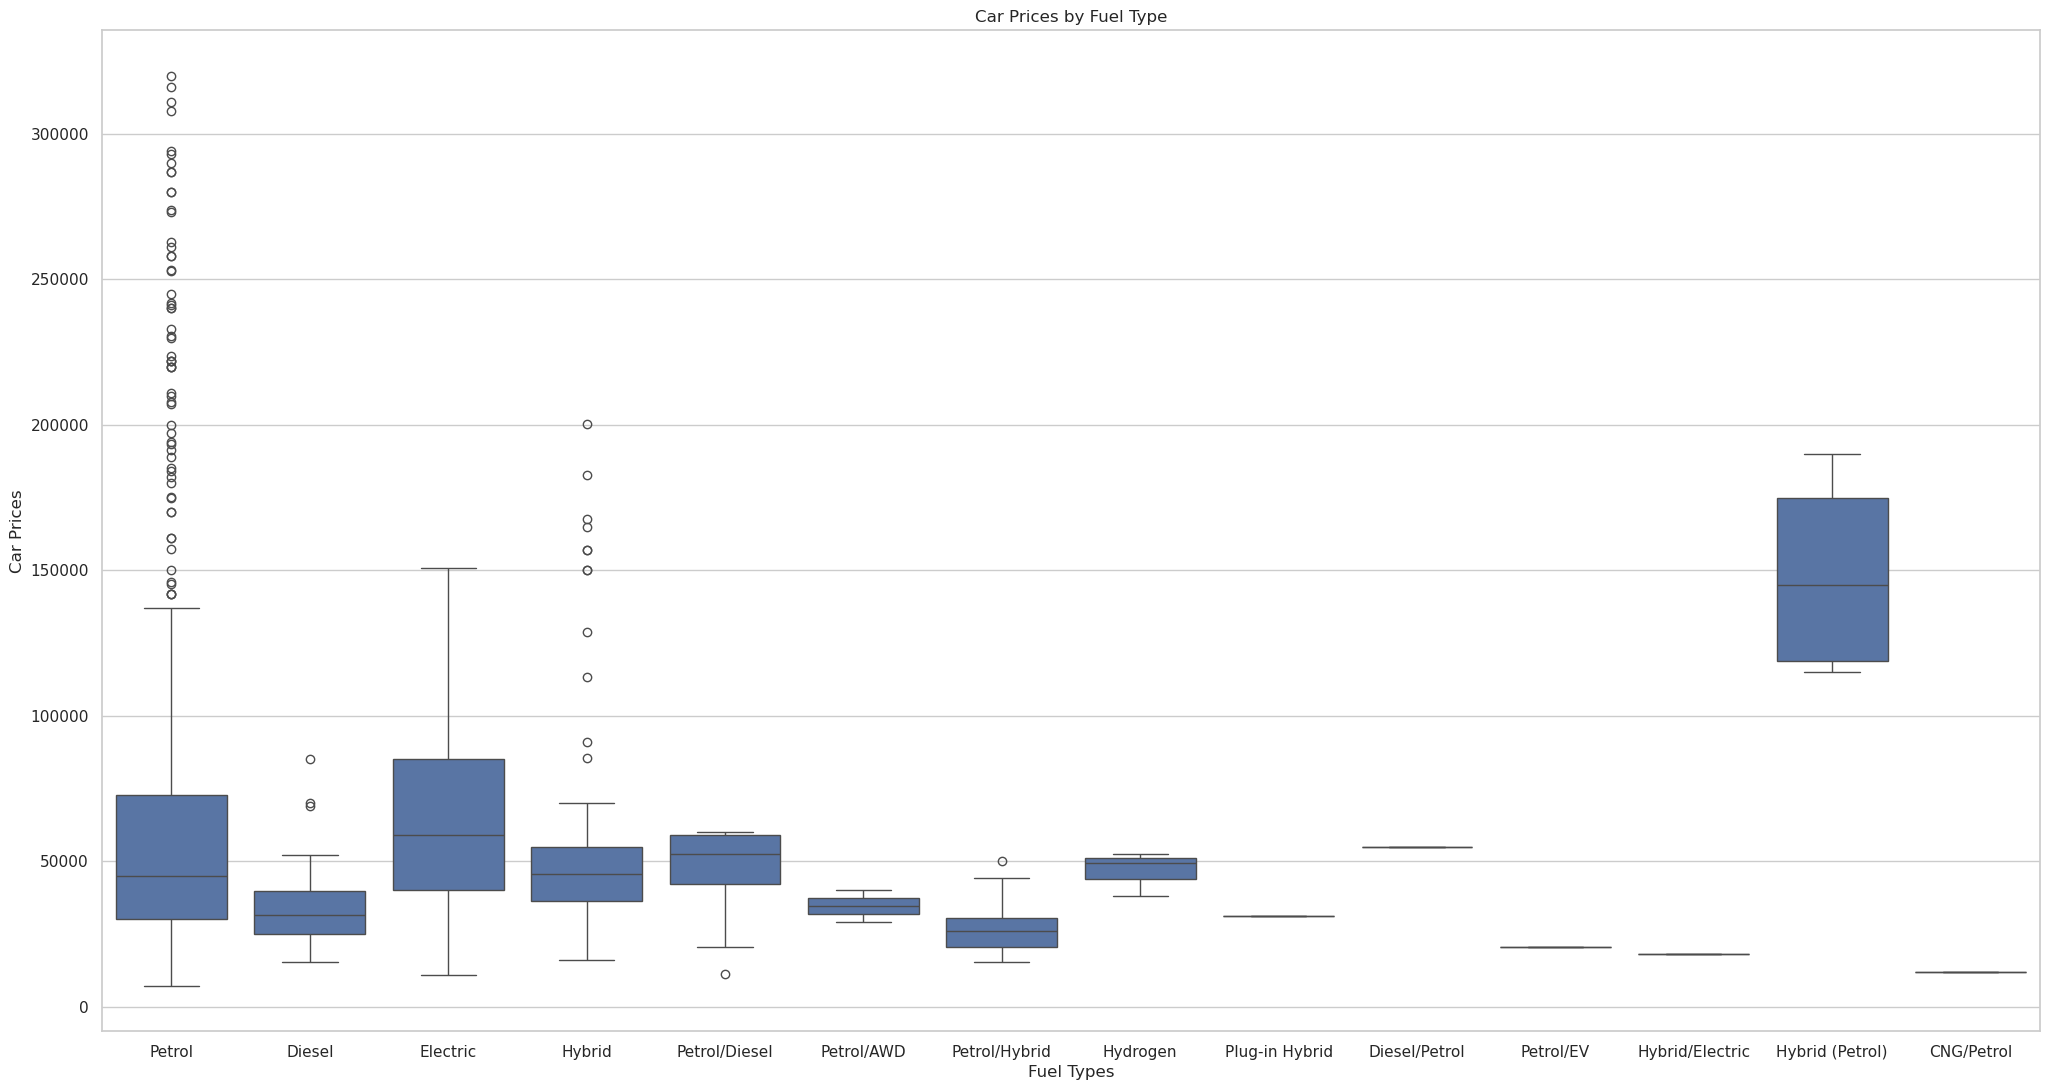

In [118]:
# Boxplot for car prices by fuel type
plt.figure(figsize=(25, 13))
sns.boxplot(data=cars_data, x='Fuel Types', y='Cars Prices')
plt.title('Car Prices by Fuel Type')
plt.xlabel('Fuel Types')
plt.ylabel('Car Prices')
plt.show()

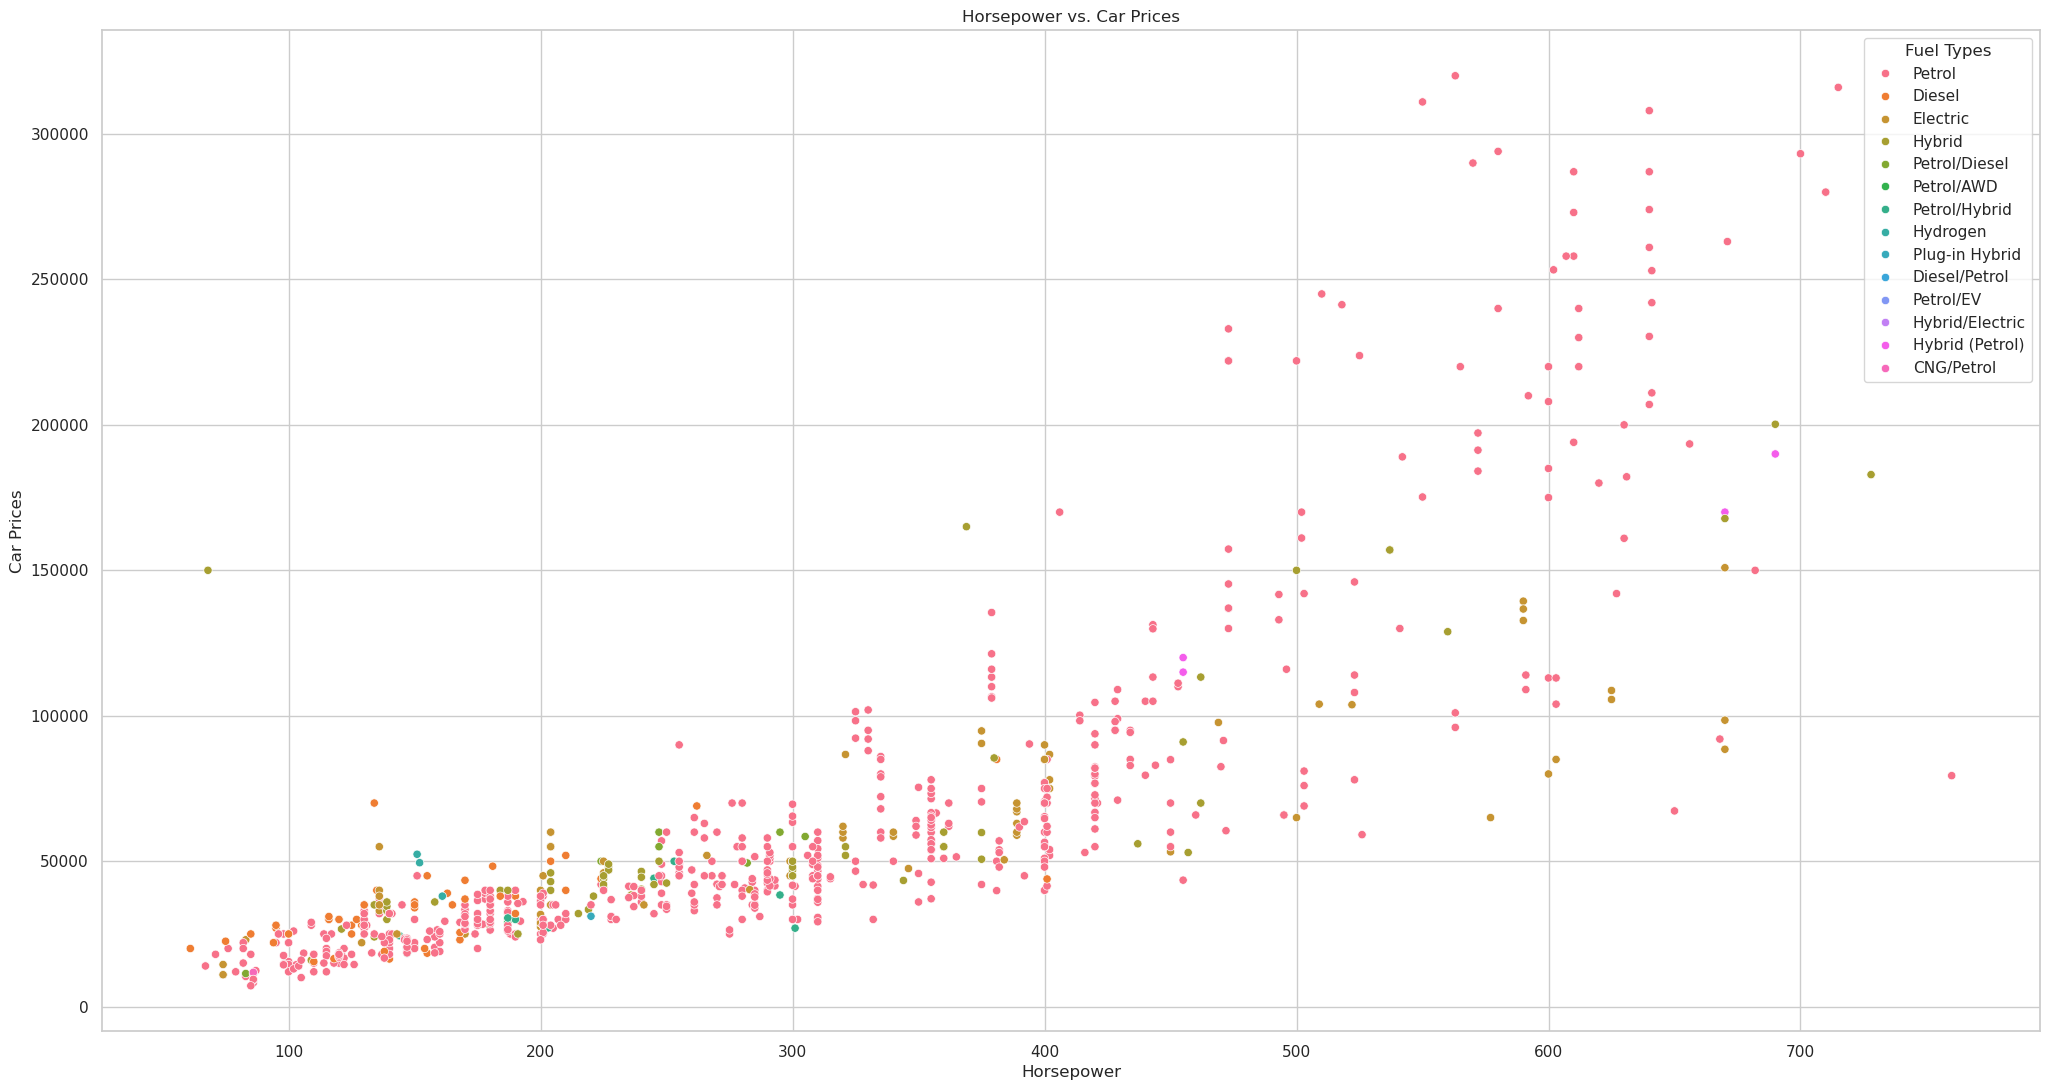

In [121]:
# Scatter plot for horsepower vs. price
plt.figure(figsize=(25, 13))
sns.scatterplot(data=cars_data, x='HorsePower', y='Cars Prices', hue='Fuel Types')
plt.title('Horsepower vs. Car Prices')
plt.xlabel('Horsepower')
plt.ylabel('Car Prices')
plt.show()

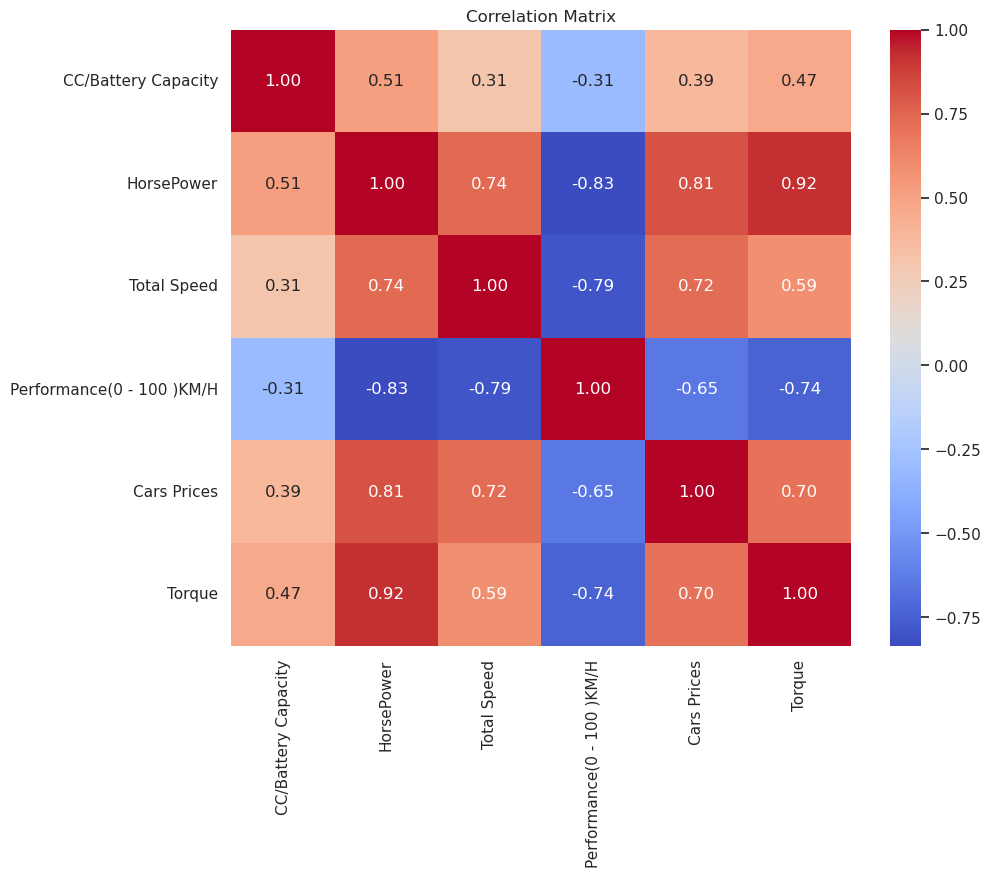

In [122]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

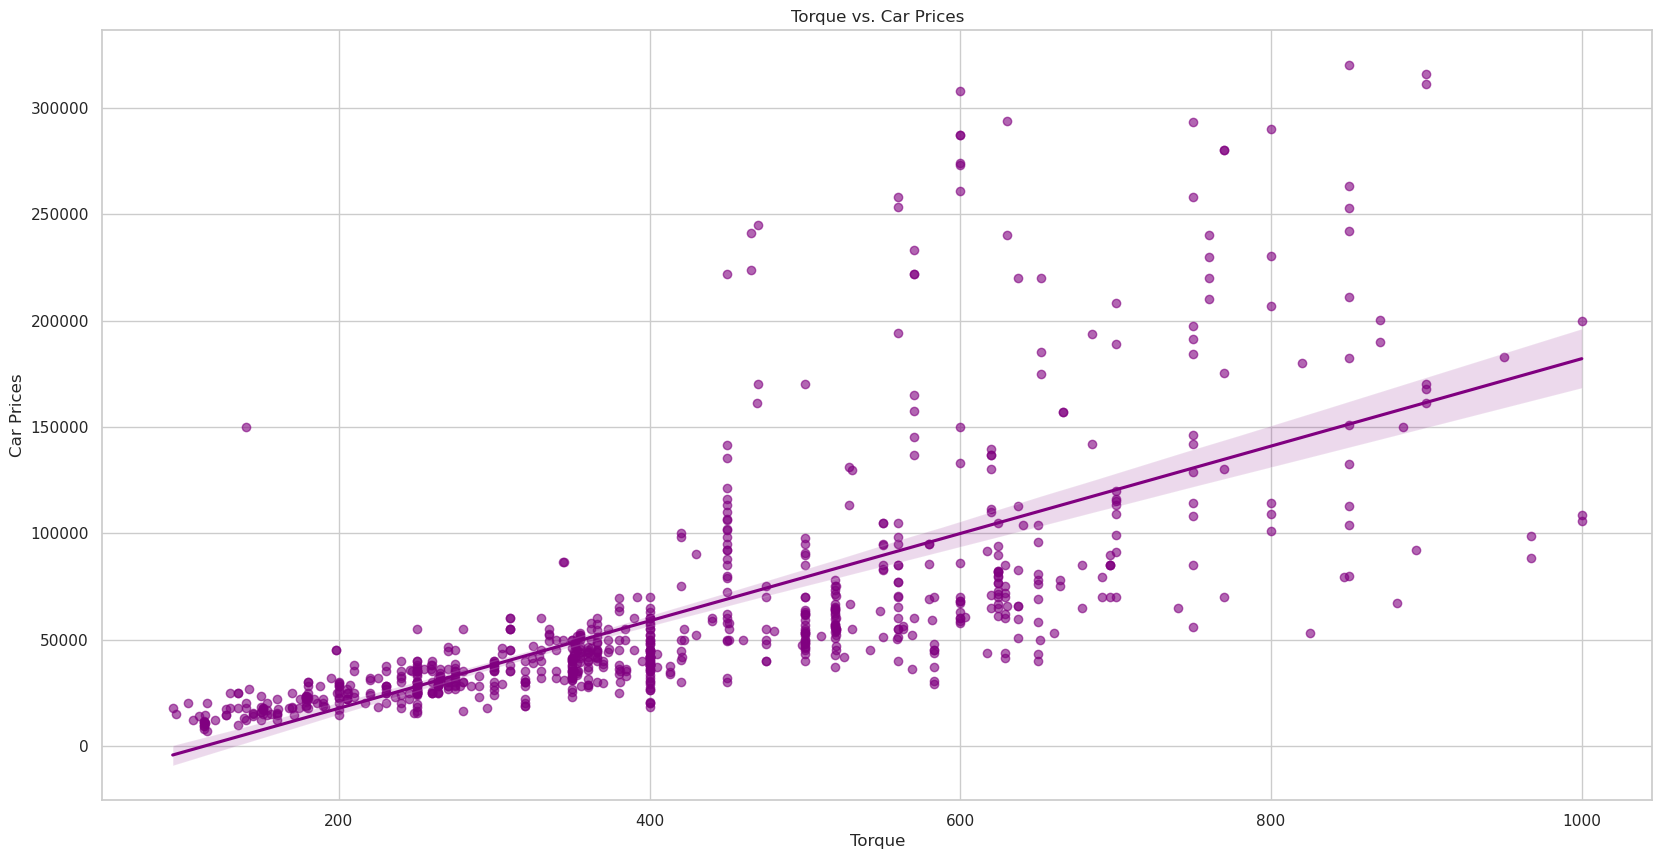

In [133]:
# Scatter plot with regression line for Torque vs. Price
plt.figure(figsize=(20, 10))
sns.regplot(data=cars_data, x='Torque', y='Cars Prices', scatter_kws={'alpha': 0.6}, color='purple')
plt.title('Torque vs. Car Prices')
plt.xlabel('Torque')
plt.ylabel('Car Prices')
plt.show()

/tmp/ipykernel_7458/557632213.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_horsepower.index, y=avg_horsepower.values, palette='Blues_d')


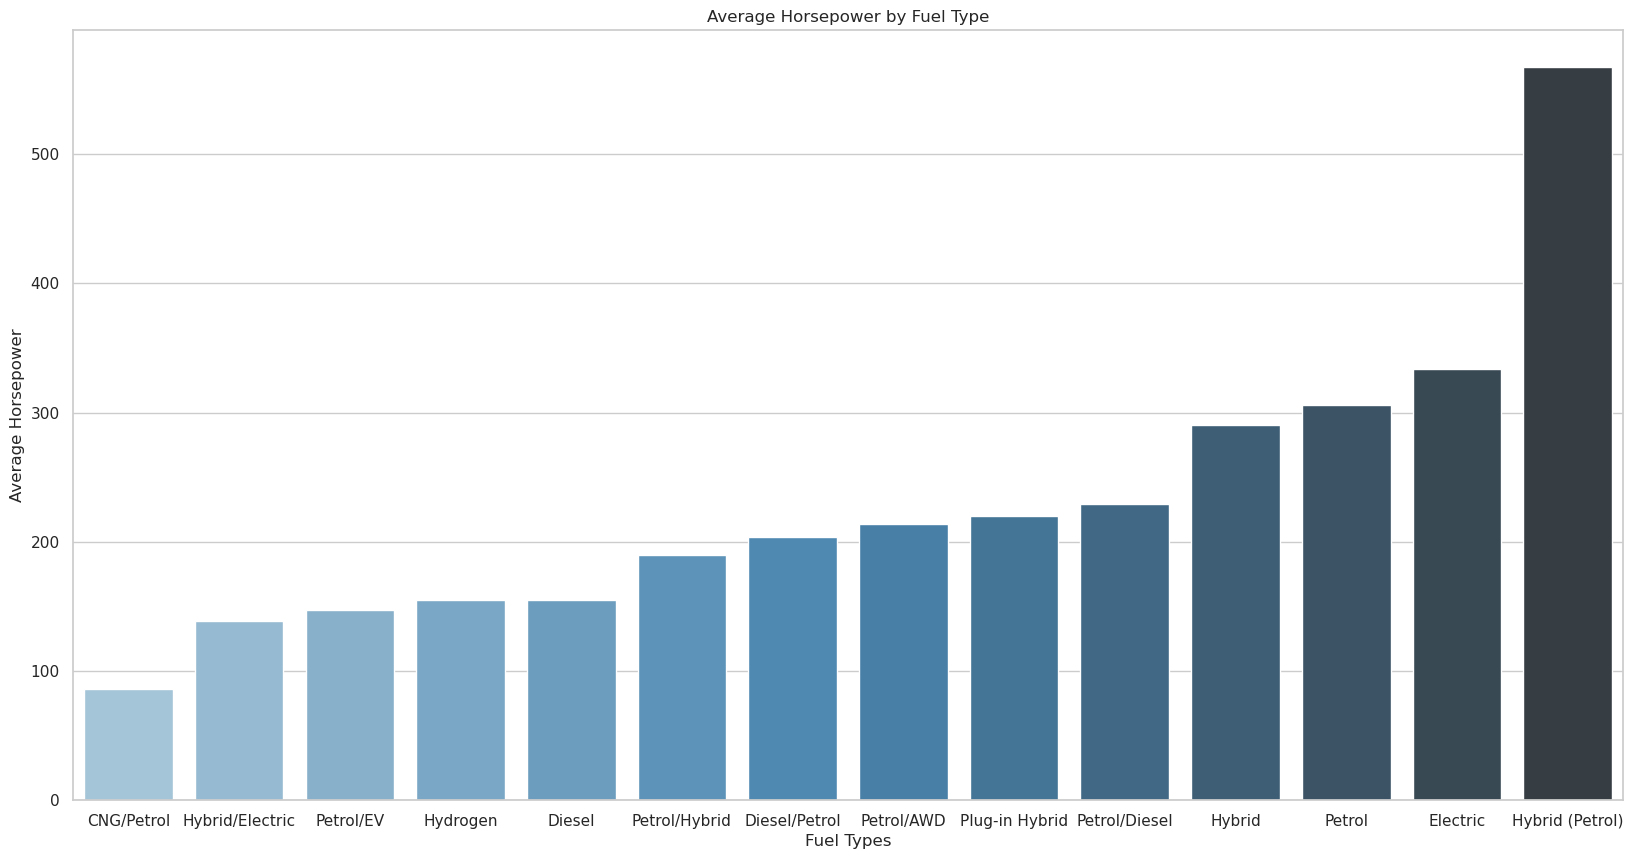

In [136]:
# Bar plot for average Horsepower by Fuel Type
avg_horsepower = cars_data.groupby('Fuel Types')['HorsePower'].mean().sort_values()
plt.figure(figsize=(20, 10))
sns.barplot(x=avg_horsepower.index, y=avg_horsepower.values, palette='Blues_d')
plt.title('Average Horsepower by Fuel Type')
plt.xlabel('Fuel Types')
plt.ylabel('Average Horsepower')
plt.show()


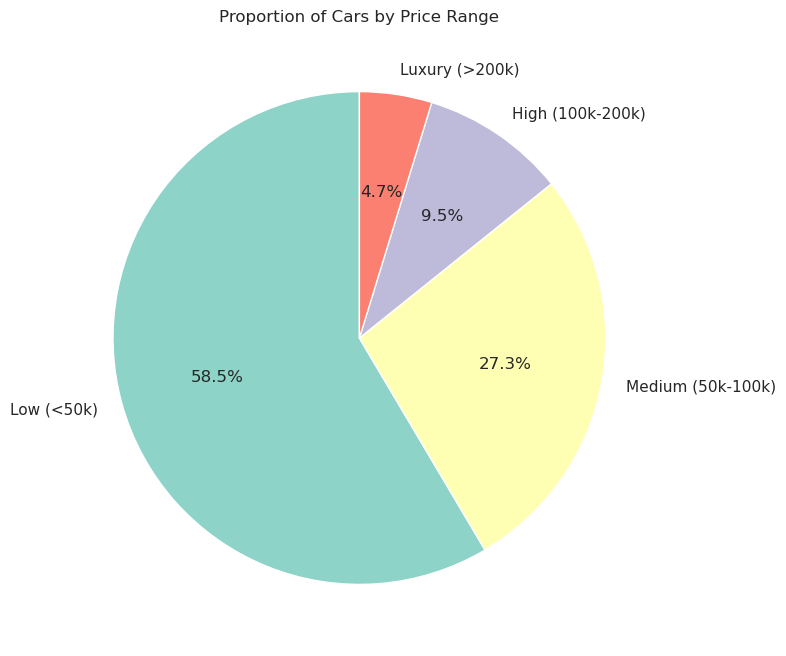

In [144]:
# Group cars into price ranges
bins = [0, 50000, 100000, 200000, np.inf]
labels = ['Low (<50k)', 'Medium (50k-100k)', 'High (100k-200k)', 'Luxury (>200k)']
cars_data['Price Range'] = pd.cut(cars_data['Cars Prices'], bins=bins, labels=labels)

# Pie chart for price range
price_range_counts = cars_data['Price Range'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(price_range_counts, labels=price_range_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3'))
plt.title('Proportion of Cars by Price Range')
plt.show()


**Hypothesis Testing**

In [125]:
# Hypothesis 1: Cars with higher horsepower have significantly higher prices.
high_hp = cars_data[cars_data['HorsePower'] > cars_data['HorsePower'].median()]['Cars Prices']
low_hp = cars_data[cars_data['HorsePower'] <= cars_data['HorsePower'].median()]['Cars Prices']
t_stat, p_value = ttest_ind(high_hp, low_hp)
print(f"\nHypothesis 1: t-statistic = {t_stat:.2f}, p-value = {p_value:.4f}")


Hypothesis 1: t-statistic = 19.34, p-value = 0.0000


In [126]:
# Hypothesis 2: Fuel type is associated with car prices.
contingency_table = pd.crosstab(cars_data['Fuel Types'], cars_data['Cars Prices'] > cars_data['Cars Prices'].median())
chi2, p_value, _, _ = chi2_contingency(contingency_table)
print(f"Hypothesis 2: chi-square = {chi2:.2f}, p-value = {p_value:.4f}")

Hypothesis 2: chi-square = 61.39, p-value = 0.0000


**Advanced Analysis (Clustering Example)**

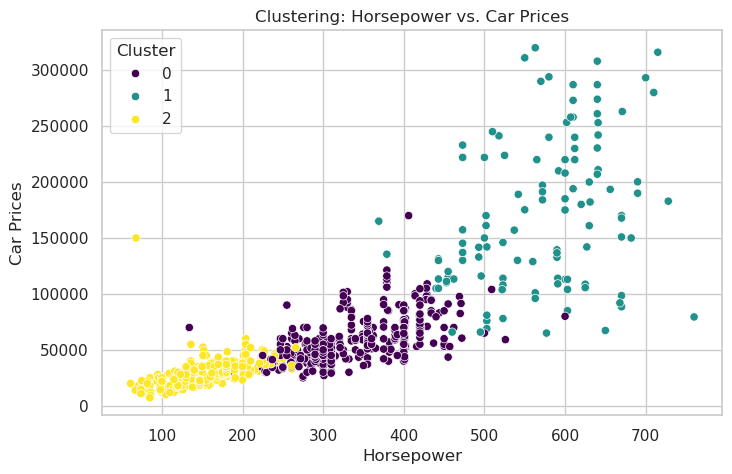

In [128]:
# Normalize numeric features for clustering
scaler = StandardScaler()
normalized_data = scaler.fit_transform(cars_data[numeric_columns])

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
cars_data['Cluster'] = kmeans.fit_predict(normalized_data)

# Visualize clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(data=cars_data, x='HorsePower', y='Cars Prices', hue='Cluster', palette='viridis')
plt.title('Clustering: Horsepower vs. Car Prices')
plt.xlabel('Horsepower')
plt.ylabel('Car Prices')
plt.show()

**Save Cleaned and Analyzed Data**

In [145]:
cars_data.to_csv('Final_Cleaned_Cars_Dataset.csv', index=False)
